In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter


In [5]:

def plot_boxplots(ax, data, plot_title, number_plots, plots_ticks, yticks, ylim):
    # Set fonts (safe for Colab)
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "mathtext.fontset": "cm",
    })

    # Create boxplot on the given axes
    box = ax.boxplot(data, notch=True, patch_artist=True, widths=0.4)

    for patch in box['boxes']:
        patch.set(facecolor='lightgray')

    # Scientific formatting
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((3, 3)) # Forzamos la potencia a ser 3
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.offsetText.set_fontsize(26)
    ax.yaxis.offsetText.set_text('$\\times 10^3$') # Establecemos el texto directamente


    ax.set_xticks(np.arange(1, number_plots + 1))
    ax.set_xticklabels(plots_ticks, fontsize=30, rotation=90)
    ax.set_yticks(yticks)
    ax.set_ylim(ylim)

    ax.tick_params(axis='y', labelsize=30)

    
    



In [3]:
# Read and evaluate the file
with open('resultados_David.txt', 'r') as file:
    content = file.read()

# Evaluate the dictionary using eval (safe only if you trust the file source)
score_dict = eval(content, {"__builtins__": None}, {"array": np.array})
score_dict.keys()

dict_keys(['init-hm-020', 'init-hm-100', 'init-ts-020', 'init-ts-100', 'init-agg-020', 'init-agg-100'])

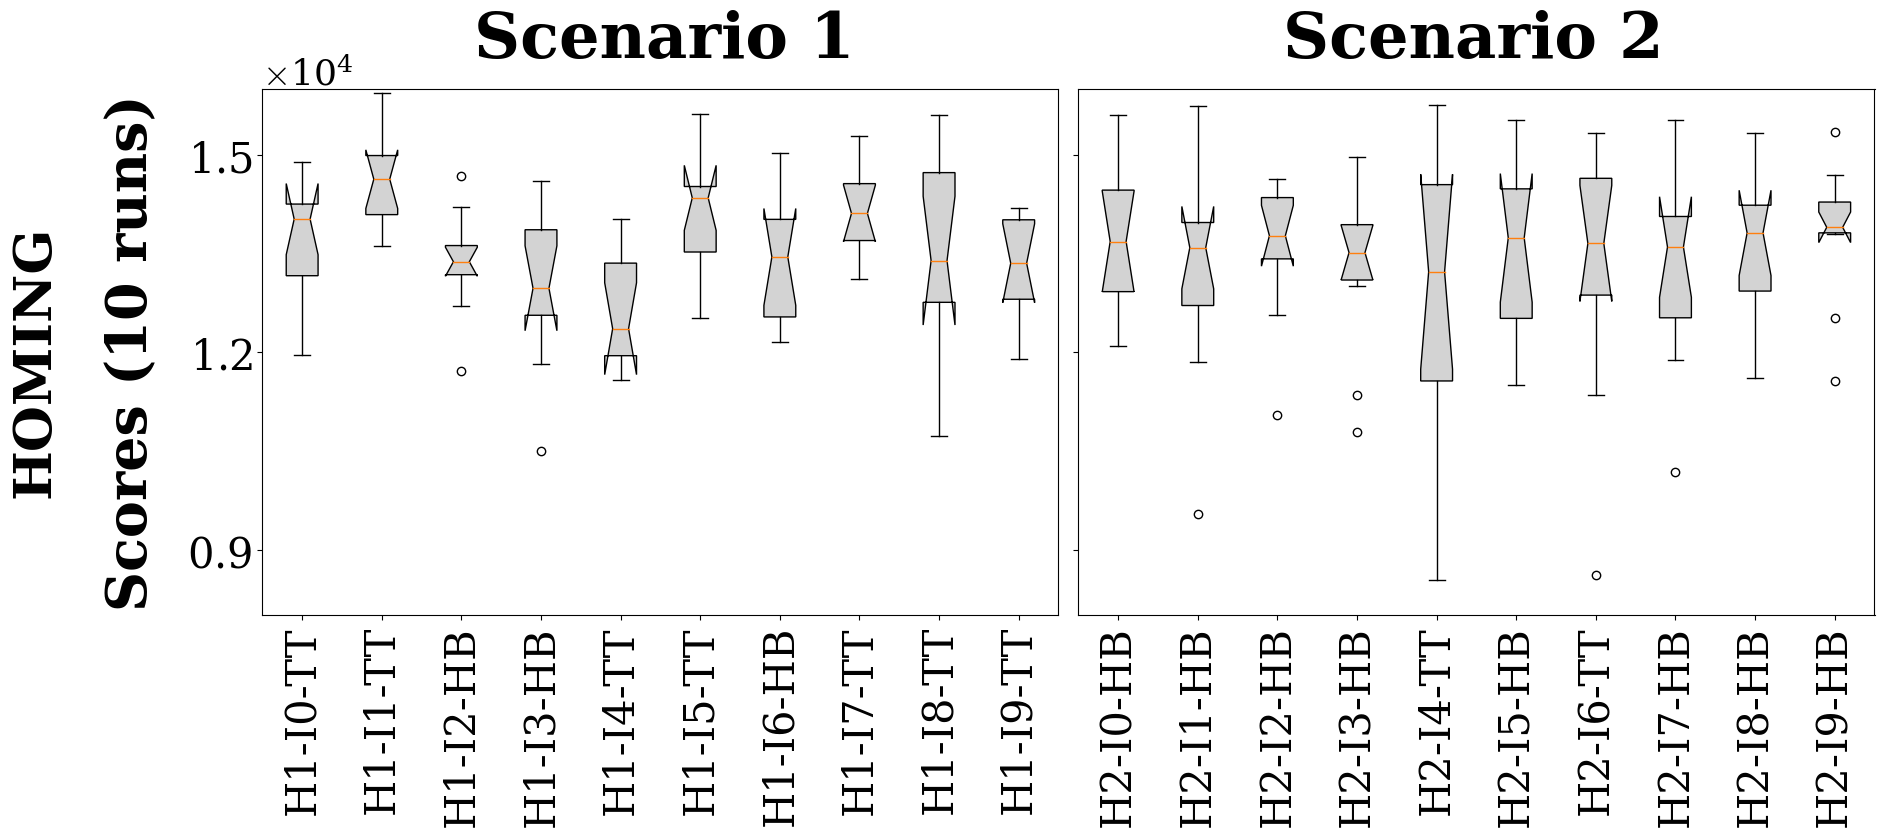

In [60]:
# === Prepare data ===
mission1 = 'init-hm-100'
mission2 = 'init-hm-020'

data1 = [-values for values in score_dict[mission1]]
data2 = [-values for values in score_dict[mission2]]

ticks1 = ['H1-I0-TT', 'H1-I1-TT', 'H1-I2-HB', 'H1-I3-HB', 'H1-I4-TT', 'H1-I5-TT', 'H1-I6-HB', 'H1-I7-TT', 'H1-I8-TT', 'H1-I9-TT'] 
ticks2 = ['H2-I0-HB', 'H2-I1-HB', 'H2-I2-HB', 'H2-I3-HB', 'H2-I4-TT', 'H2-I5-HB', 'H2-I6-TT', 'H2-I7-HB', 'H2-I8-HB', 'H2-I9-HB']

# === Create subplots in 1 row, 2 columns ===
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

# Only show y-label for the first plot and x-label for the second plot
plot_boxplots(axes[0], data1, 'Homing 20%', len(data1), ticks1, yticks=[9000, 12000, 15000], ylim=[8000, 16000])
plot_boxplots(axes[1], data2, 'Homing 100%', len(data2), ticks2, yticks=[9000, 12000, 15000], ylim=[8000, 16000])

# Remove y-ticks from the second plot to avoid duplication
axes[1].set_yticklabels([])

# Set the x-axis label in the middle of the figure
# fig.text(0.5, -0.05, "Instances of control software", ha='center', fontsize=32)

# Get bounding boxes of the axes
start_ax = axes[0]
end_ax   = axes[1]

# Get center x-coordinates of each column in figure coordinates
start_center = start_ax.get_position().x0 + start_ax.get_position().width / 2
end_center   = end_ax.get_position().x0 + end_ax.get_position().width / 2

# Add labels
fig.text(-0.03, 0.6, 'HOMING', va='center', ha='center', rotation='vertical', fontsize=38, fontweight='bold')
fig.text(start_center+0.018, 0.98, 'Scenario 1', ha='center', fontsize=46, fontweight='bold')
fig.text(end_center+0.045, 0.98, 'Scenario 2', ha='center', fontsize=46, fontweight='bold')

# Set the y-axis label only for the first plot
axes[0].set_ylabel("Scores (10 runs)", fontsize=40, labelpad=20,fontweight='bold')

plt.tight_layout()
plt.savefig("ALIFE_images/hom_performance.pdf", format='pdf', bbox_inches='tight')
plt.show()


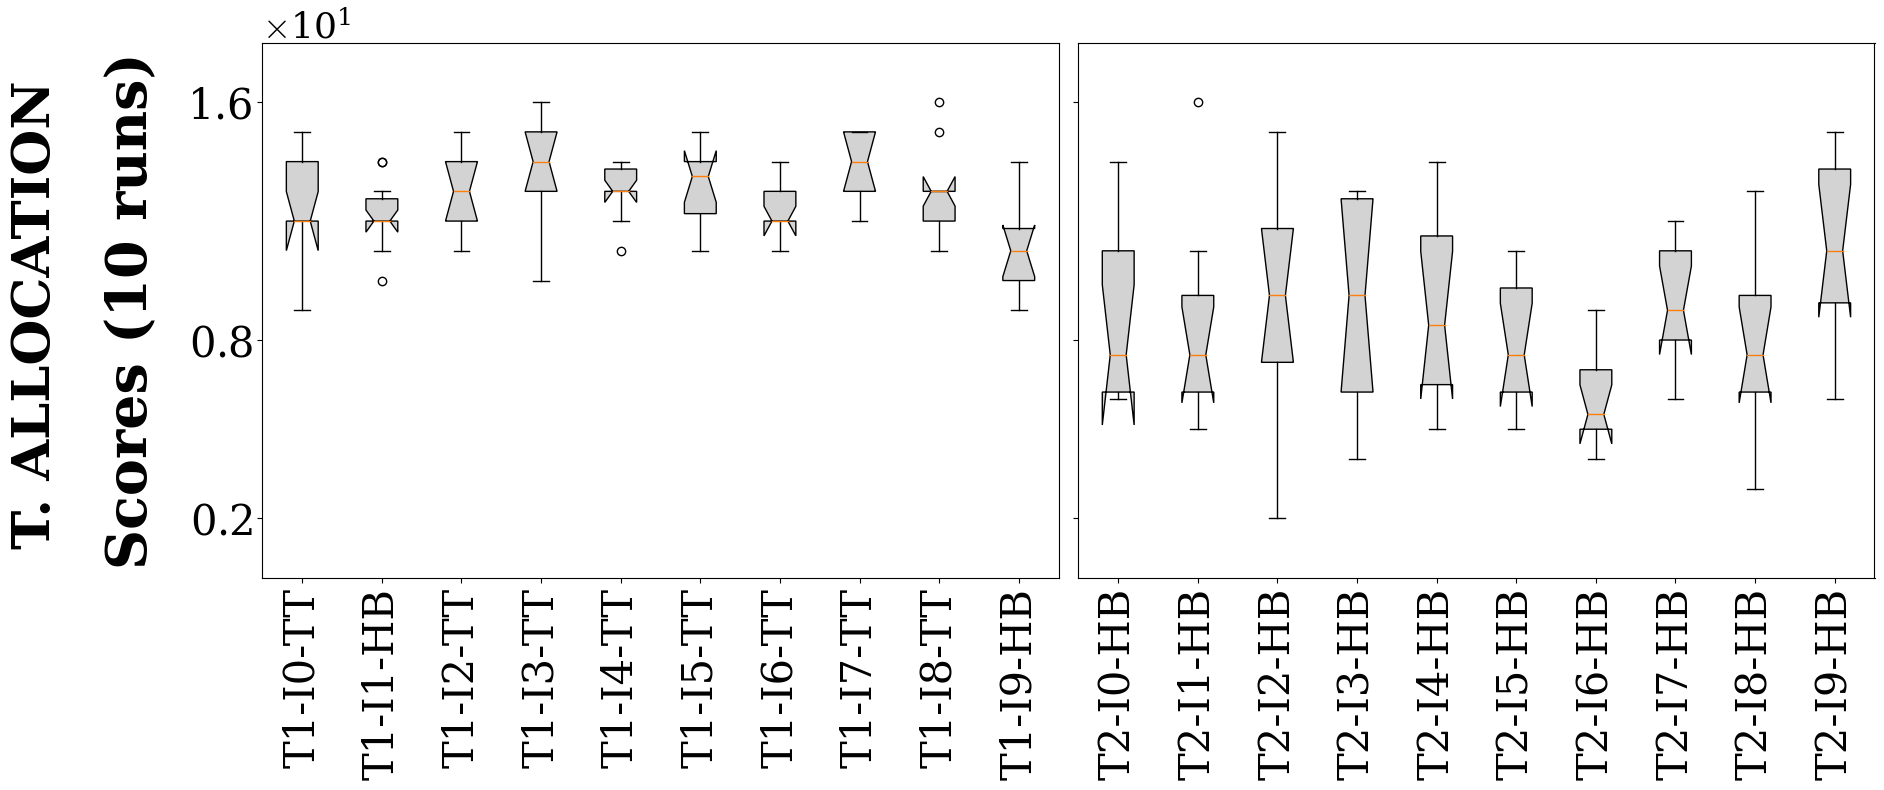

In [86]:
# === Prepare data ===
mission1 = 'init-ts-100'
mission2 = 'init-ts-020'

data1 = [-values for values in score_dict[mission1]]
data2 = [-values for values in score_dict[mission2]]

ticks1 = ['T1-I0-TT', 'T1-I1-HB', 'T1-I2-TT', 'T1-I3-TT', 'T1-I4-TT', 'T1-I5-TT', 'T1-I6-TT', 'T1-I7-TT', 'T1-I8-TT', 'T1-I9-HB']
ticks2 = ['T2-I0-HB', 'T2-I1-HB', 'T2-I2-HB', 'T2-I3-HB', 'T2-I4-HB', 'T2-I5-HB', 'T2-I6-HB', 'T2-I7-HB', 'T2-I8-HB', 'T2-I9-HB']

# === Create subplots in 1 row, 2 columns ===
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

# Only show y-label for the first plot and x-label for the second plot
plot_boxplots(axes[0], data1, 'Homing 20%', len(data1), ticks1, yticks=[2, 8, 16], ylim=[0, 18])
plot_boxplots(axes[1], data2, 'Homing 100%', len(data2), ticks2, yticks=[2, 8, 16], ylim=[0, 18])

# Remove y-ticks from the second plot to avoid duplication
axes[1].set_yticklabels([])

# Set the x-axis label in the middle of the figure
# fig.text(0.5, -0.05, "Instances of control software", ha='center', fontsize=32)

# Add labels
fig.text(-0.03, 0.6, 'T. ALLOCATION', va='center', ha='center', rotation='vertical', fontsize=38, fontweight='bold')
# fig.text(0.31, 1.02, 'Scenario 1', ha='center', fontsize=32)
# fig.text(0.76, 1.02, 'Scenario 2', ha='center', fontsize=32)

# Set the y-axis label only for the first plot
axes[0].set_ylabel("Scores (10 runs)", fontsize=40, labelpad=20, fontweight='bold')

plt.tight_layout()
plt.savefig("ALIFE_images/tsk_performance.pdf", format='pdf', bbox_inches='tight')
plt.show()


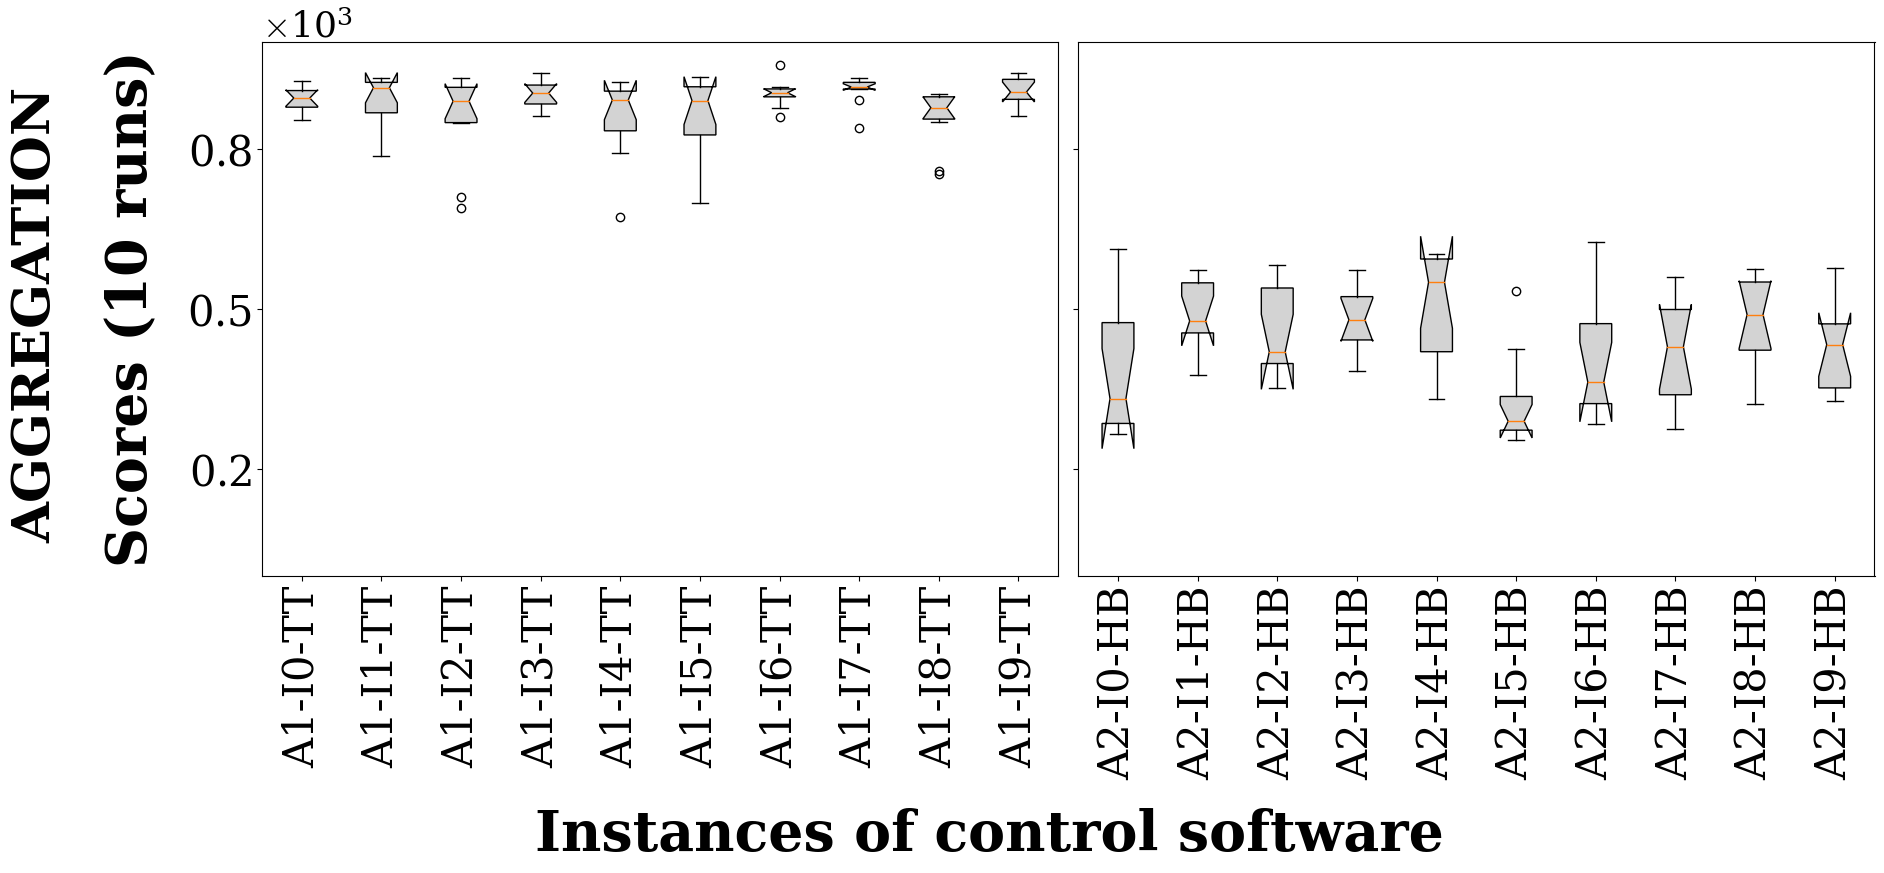

In [6]:
# === Prepare data ===
mission1 = 'init-agg-020'
mission2 = 'init-agg-100'

data1 = [values for values in score_dict[mission1]]
data2 = [values for values in score_dict[mission2]]

ticks1 = ['A1-I0-TT', 'A1-I1-TT', 'A1-I2-TT', 'A1-I3-TT', 'A1-I4-TT', 'A1-I5-TT', 'A1-I6-TT', 'A1-I7-TT', 'A1-I8-TT', 'A1-I9-TT']
ticks2 = ['A2-I0-HB', 'A2-I1-HB', 'A2-I2-HB', 'A2-I3-HB', 'A2-I4-HB', 'A2-I5-HB', 'A2-I6-HB', 'A2-I7-HB', 'A2-I8-HB', 'A2-I9-HB']

# === Create subplots in 1 row, 2 columns ===
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

# Only show y-label for the first plot and x-label for the second plot
plot_boxplots(axes[0], data1, 'Homing 20%', len(data1), ticks1, yticks=[200, 500, 800], ylim=[0, 1000])
plot_boxplots(axes[1], data2, 'Homing 100%', len(data2), ticks2, yticks=[200, 500, 800], ylim=[0, 1000])

# Remove y-ticks from the second plot to avoid duplication
axes[1].set_yticklabels([])

# Set the x-axis label in the middle of the figure
fig.text(0.5, -0.07, "Instances of control software", ha='center', fontsize=40, fontweight='bold')

# Add labels
fig.text(-0.03, 0.6, 'AGGREGATION', va='center', ha='center', rotation='vertical', fontsize=38, fontweight='bold')
# fig.text(0.31, 0.98, 'Scenario 1', ha='center', fontsize=32)
# fig.text(0.76, 0.98, 'Scenario 2', ha='center', fontsize=32)

# Set the y-axis label only for the first plot
axes[0].set_ylabel("Scores (10 runs)", fontsize=40, labelpad=20, fontweight='bold')

plt.tight_layout()
plt.savefig("ALIFE_images/agg_performance.pdf", format='pdf', bbox_inches='tight')
plt.show()


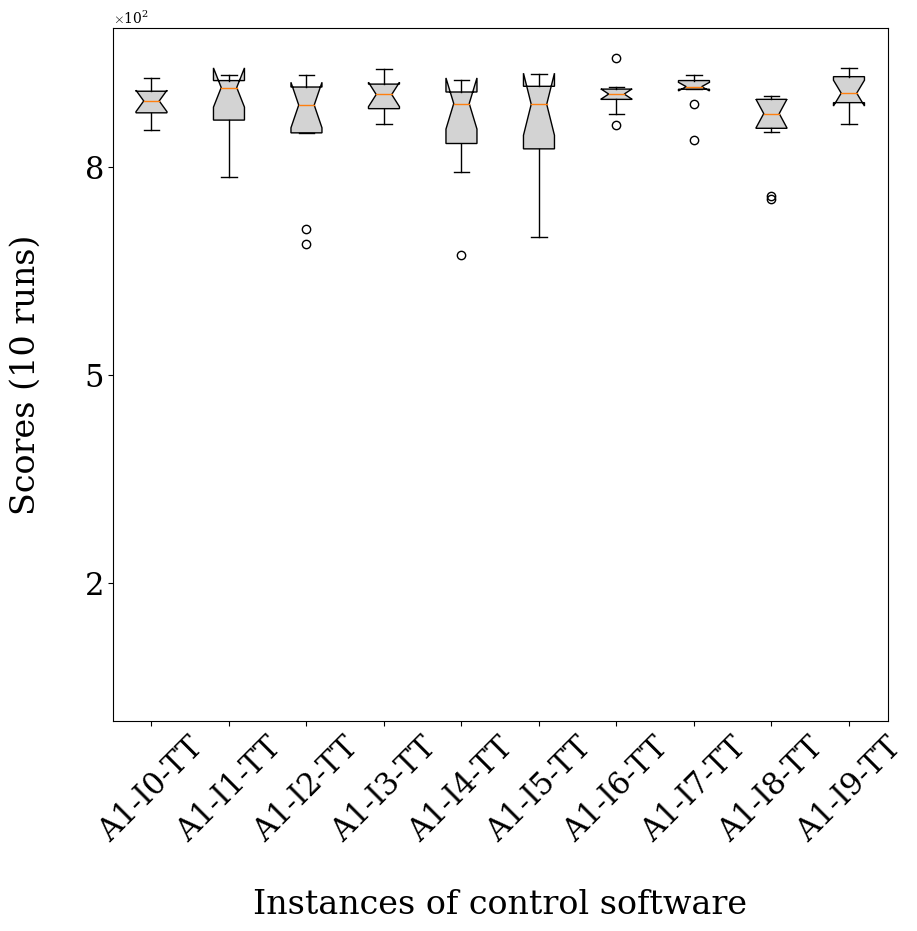

In [8]:
mission_name = 'init-agg-020'

plt.figure(figsize=(10, 9)) 

plot_boxplots([values for values in score_dict[mission_name]], 'Tasking 100%', number_plots=len(score_dict[mission_name]), 
              plots_ticks=['A1-I0-TT', 'A1-I1-TT', 'A1-I2-TT', 'A1-I3-TT', 'A1-I4-TT', 'A1-I5-TT', 'A1-I6-TT', 'A1-I7-TT', 'A1-I8-TT', 'A1-I9-TT'],
              yticks=[200, 500, 800], ylim=[0, 1000])

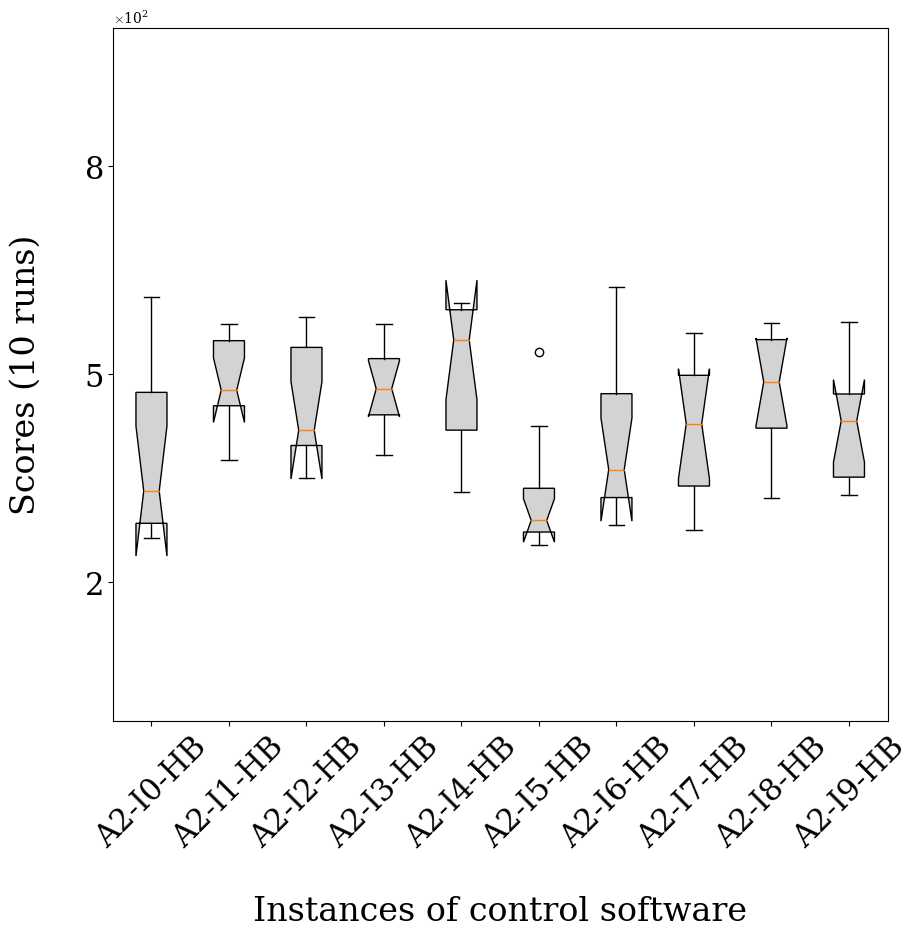

In [ ]:
mission_name = 'init-agg-100'

plt.figure(figsize=(10, 9)) 

plot_boxplots([values for values in score_dict[mission_name]], 'Tasking 100%', number_plots=len(score_dict[mission_name]), 
              plots_ticks=['A2-I0-HB', 'A2-I1-HB', 'A2-I2-HB', 'A2-I3-HB', 'A2-I4-HB', 'A2-I5-HB', 'A2-I6-HB', 'A2-I7-HB', 'A2-I8-HB', 'A2-I9-HB'],
              yticks=[200, 500, 800], ylim=[0, 1000])